# Les Dataframes en Pratique

## 1 Instructions

Nous jouerons dans ce TP  avec les fonctionnalités des DataFrames.

Utilisez la documentation sur l'API des DataFrames pour répondre aux questions qui vous seront posées dans ce TP.

https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/dataframe.html

Dans ce TP, vous utiliserez le notebook pour exécuter vos programmes à partir des cellules code reconnaissables avec [] .



## 2 Pré-requis




### Démarrer HDFS

### Démarrez votre cluster Spark

Pour démarrer votre cluster Spark, si cela n'a pas déjà été fait, vous devrez ouvrir un terminal puis exécuter la commande suivante :

Vérifiez que les containers smaster, sworker1 et sworker2 sont démarrés :

### Connexion à Spark

Pour établir une connexion avec le cluster Spark en python à partir de ce notebook, exécutez la cellule ci-dessous  :

In [2]:
# N'oubliez pas de fermer la connexion à la fin du TP
# spark.stop()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("spark://smaster:7077").appName("TPDF03").getOrCreate()

La variable "spark" est un objet de type SparkContext et c'est via cette variable que nous soumettrons des programmes distribués.

On peut vérifier notre connexion avec la commande suivante :
    

In [3]:
spark

## Exercice

Nous allons travailler sur les données concernant la bourse du marché des pommes.

#### Ouvrer le fichier appl_stock.csv et chargez le dans un dataframe. 

In [24]:
# compléter votre réponse


#### Afficher un extrait des données :

In [25]:
# compléter votre réponse


+----------+------------------+------------------+------------------+------------------+---------+------------------+
|      Date|              Open|              High|               Low|             Close|   Volume|         Adj Close|
+----------+------------------+------------------+------------------+------------------+---------+------------------+
|2010-01-04|        213.429998|        214.499996|212.38000099999996|        214.009998|123432400|         27.727039|
|2010-01-05|        214.599998|        215.589994|        213.249994|        214.379993|150476200|27.774976000000002|
|2010-01-06|        214.379993|            215.23|        210.750004|        210.969995|138040000|27.333178000000004|
|2010-01-07|            211.75|        212.000006|        209.050005|            210.58|119282800|          27.28265|
|2010-01-08|        210.299994|        212.000006|209.06000500000002|211.98000499999998|111902700|         27.464034|
|2010-01-11|212.79999700000002|        213.000002|      

#### Afficher la structure, les types du schema 

In [26]:
# compléter votre réponse


root
 |-- Date: string (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Adj Close: double (nullable = true)



#### Le résultat vous convient il ?

In [9]:
# compléter votre réponse



Une autre manière de convertir les types des colonnes est d'utiliser la méthode cast :
https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Column.cast.html#pyspark.sql.Column.cast


In [13]:
# on définit les types appropriés

from pyspark.sql.types import *
from pyspark.sql.functions import col,struct
    
df2 = df.select(col("Date").cast(DateType()),"Open","High","Low","Close","Volume","Adj")
df2.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Adj: double (nullable = true)



#### Créer un dataframe df_closure contenant les dates et le prix des pommes à la clôture de la bourse ?

In [1]:
# compléter votre réponse


NameError: name 'df' is not defined

On peut afficher l'évoution des prix à la fermeture avec une courbe :

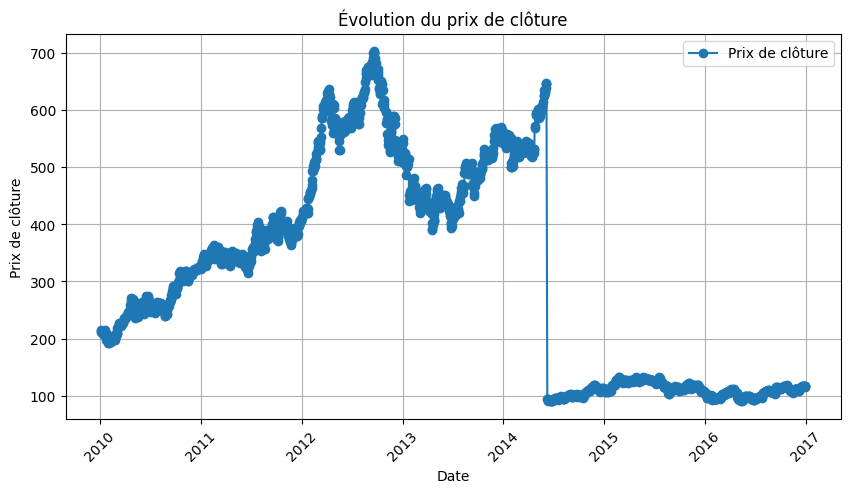

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Simuler un DataFrame Pandas (en supposant que `sql_sales` est converti en Pandas)
# Dans un cas réel, utiliser : sql_sales_pandas = sql_sales.toPandas()
sql_sales_pandas = df_closure.toPandas()
# Tracer l'évolution du prix
plt.figure(figsize=(10, 5))
plt.plot(sql_sales_pandas["Date"], sql_sales_pandas["Close"], marker='o', linestyle='-', label="Prix de clôture")

# Ajouter des titres et labels
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.title("Évolution du prix de clôture")
plt.xticks(rotation=45)
plt.legend()

# Afficher le graphique
plt.grid()
plt.show()

On y voit quand même plus clair, vous ne trouvez pas !

#### Afficher les dates et le prix des pommes à la clôture de la bourse qui sont inférieur à 300.

In [14]:
# compléter votre réponse


+----------+------------------+
|      Date|             Close|
+----------+------------------+
|2010-01-04|        214.009998|
|2010-01-05|        214.379993|
|2010-01-06|        210.969995|
|2010-01-07|            210.58|
|2010-01-08|211.98000499999998|
|2010-01-11|210.11000299999998|
|2010-01-12|        207.720001|
|2010-01-13|        210.650002|
|2010-01-14|            209.43|
|2010-01-15|            205.93|
|2010-01-19|        215.039995|
|2010-01-20|            211.73|
|2010-01-21|        208.069996|
|2010-01-22|            197.75|
|2010-01-25|        203.070002|
|2010-01-26|        205.940001|
|2010-01-27|        207.880005|
|2010-01-28|        199.289995|
|2010-01-29|        192.060003|
|2010-02-01|        194.729998|
+----------+------------------+
only showing top 20 rows



#### Retourner les lignes sur lesquels le prix à la clotûre est < 200 et dont le prix à l'ouverture est > 200

In [20]:
# compléter votre réponse


+----------+------------------+----------+----------+----------+---------+------------------+
|      Date|              Open|      High|       Low|     Close|   Volume|               Adj|
+----------+------------------+----------+----------+----------+---------+------------------+
|2010-01-22|206.78000600000001|207.499996|    197.16|    197.75|220441900|         25.620401|
|2010-01-28|        204.930004|205.500004|198.699995|199.289995|293375600|25.819922000000002|
|2010-01-29|        201.079996|202.199995|190.250002|192.060003|311488100|         24.883208|
+----------+------------------+----------+----------+----------+---------+------------------+



#### Donner les statistiques sur l'ensemble des colonnes

In [21]:
# compléter votre réponse


+-------+------------------+------------------+------------------+-----------------+-------------------+------------------+
|summary|              Open|              High|               Low|            Close|             Volume|               Adj|
+-------+------------------+------------------+------------------+-----------------+-------------------+------------------+
|  count|              1762|              1762|              1762|             1762|               1762|              1762|
|   mean| 313.0763111589103| 315.9112880164581| 309.8282405079457|312.9270656379113|9.422577587968218E7| 75.00174115607275|
| stddev|185.29946803981522|186.89817686485767|183.38391664371008|185.1471036170943|6.020518776592709E7| 28.57492972179906|
|    min|              90.0|         90.699997|         89.470001|        90.279999|           11475900|         24.881912|
|    max|        702.409988|        705.070023|        699.569977|       702.100021|          470249500|127.96609099999999|
+-------

#### Ajouter une colonne Year qui mentionnera uniquement l'année de vente .<br/>
Indice: utilisez la fonction year pour extraire l'année du champs Date.

On retournera le résultat dans un nouveau dataframe `new_df`

In [17]:
from pyspark.sql.functions import year
# compléter votre réponse


+----------+----------+----------+------------------+------------------+---------+------------------+----+
|      Date|      Open|      High|               Low|             Close|   Volume|               Adj|Year|
+----------+----------+----------+------------------+------------------+---------+------------------+----+
|2010-01-04|213.429998|214.499996|212.38000099999996|        214.009998|123432400|         27.727039|2010|
|2010-01-05|214.599998|215.589994|        213.249994|        214.379993|150476200|27.774976000000002|2010|
|2010-01-06|214.379993|    215.23|        210.750004|        210.969995|138040000|27.333178000000004|2010|
|2010-01-07|    211.75|212.000006|        209.050005|            210.58|119282800|          27.28265|2010|
|2010-01-08|210.299994|212.000006|209.06000500000002|211.98000499999998|111902700|         27.464034|2010|
+----------+----------+----------+------------------+------------------+---------+------------------+----+
only showing top 5 rows



## Les fonctions d'aggrégation

#### Déterminer le prix moyen par année de l'ensemble des colonnes de `new_df`:

Indice: Utiliser groupBy, mean, drop

In [18]:
# compléter votre réponse


+----+------------------+------------------+------------------+------------------+--------------------+------------------+
|Year|         avg(Open)|         avg(High)|          avg(Low)|        avg(Close)|         avg(Volume)|          avg(Adj)|
+----+------------------+------------------+------------------+------------------+--------------------+------------------+
|2015|120.17575393253965|121.24452385714291| 118.8630954325397|120.03999980555547|  5.18378869047619E7|115.96740080555561|
|2013| 473.1281355634922| 477.6389272301587|468.24710264682557| 472.6348802857143|          1.016087E8| 62.61798788492063|
|2014| 295.1426195357143|297.56103184523823| 292.9949599801587| 295.4023416507935| 6.315273055555555E7| 87.63583323809523|
|2012|     576.652720788| 581.8254008040001| 569.9211606079999| 576.0497195640002|       1.319642044E8| 74.81383696800002|
|2016|104.50777772619044| 105.4271825436508|103.69027771825397|104.60400786904763|  3.84153623015873E7|103.15032854761901|
|2010| 259.95761

#### Déterminez  les prix maximum, minimum et moyen à la fermeture :


In [24]:
from pyspark.sql.functions import *
# compléter votre réponse


+----------+---------+-----------------+
| Max Close|Min Close|        Avg Close|
+----------+---------+-----------------+
|702.100021|90.279999|312.9270656379113|
+----------+---------+-----------------+



#### Déterminez  les prix maximum, minimum et moyen à la clôture pour chaque année :


In [25]:
import pyspark.sql.functions as f
# compléter votre réponse


+----+------------------+----------+------------------+
|Year|         Max Close| Min Close|     Average Close|
+----+------------------+----------+------------------+
|2010|        325.470013|192.050003| 259.8424600000002|
|2011|422.23999800000007|315.320007|364.00432532142867|
|2012|        702.100021|    411.23| 576.0497195640002|
|2013|        570.090004|390.530006| 472.6348802857143|
|2014|        647.349983| 90.279999| 295.4023416507935|
|2015|             133.0|103.120003|120.03999980555547|
|2016|            118.25| 90.339996|104.60400786904763|
+----+------------------+----------+------------------+



## SQL

Vous analyserez à présent le fichier de vente à partir du langage SQL :


#### Créer une vue sales à partir du dataframe new_df qui sera consultable en SQL :   

In [19]:
# compléter votre réponse


#### Afficher la structure de la vue sales :

In [20]:
# compléter votre réponse


+--------+---------+-------+
|col_name|data_type|comment|
+--------+---------+-------+
|    Date|     date|   null|
|    Open|   double|   null|
|    High|   double|   null|
|     Low|   double|   null|
|   Close|   double|   null|
|  Volume|      int|   null|
|     Adj|   double|   null|
|    Year|      int|   null|
+--------+---------+-------+



#### Créer à partir de votre vue sales un dataframe `sql_sales` contenant  les dates et le prix des pommes à la clôture de la bourse ?

In [35]:
# compléter votre réponse


Le code suivant nous permettra facilement d'afficher l'évolution de notre dataframe généré à partir de notre vue :

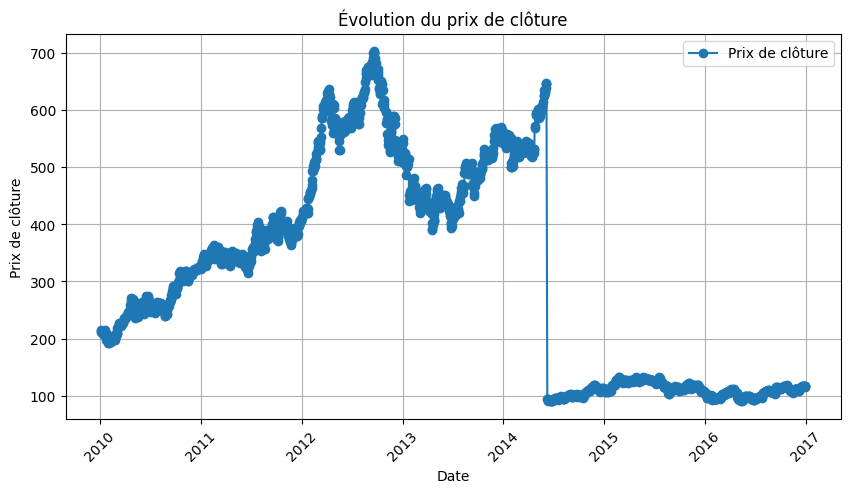

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Simuler un DataFrame Pandas (en supposant que `sql_sales` est converti en Pandas)
# Dans un cas réel, utiliser : sql_sales_pandas = sql_sales.toPandas()
sql_sales_pandas = sql_sales.toPandas()
# Tracer l'évolution du prix
plt.figure(figsize=(10, 5))
plt.plot(sql_sales_pandas["Date"], sql_sales_pandas["Close"], marker='o', linestyle='-', label="Prix de clôture")

# Ajouter des titres et labels
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.title("Évolution du prix de clôture")
plt.xticks(rotation=45)
plt.legend()

# Afficher le graphique
plt.grid()
plt.show()

#### Afficher les dates et le prix des pommes à la clôture de la bourse qui sont inférieur à 300$.

In [51]:
# compléter votre réponse


#### Créer une vue sales300byyear à partir de la requête précédente qui sera consultable en SQL :   

In [57]:
# compléter votre réponse


+----------+------------------+
|      Date|             Close|
+----------+------------------+
|2010-01-04|        214.009998|
|2010-01-05|        214.379993|
|2010-01-06|        210.969995|
|2010-01-07|            210.58|
|2010-01-08|211.98000499999998|
|2010-01-11|210.11000299999998|
|2010-01-12|        207.720001|
|2010-01-13|        210.650002|
|2010-01-14|            209.43|
|2010-01-15|            205.93|
|2010-01-19|        215.039995|
|2010-01-20|            211.73|
|2010-01-21|        208.069996|
|2010-01-22|            197.75|
|2010-01-25|        203.070002|
|2010-01-26|        205.940001|
|2010-01-27|        207.880005|
|2010-01-28|        199.289995|
|2010-01-29|        192.060003|
|2010-02-01|        194.729998|
+----------+------------------+
only showing top 20 rows



#### Déterminer  les prix maximum `maxclosure`, minimum `minclosure`et moyen `avgclosure`à la clôture pour chaque année `year` sur la vue sales300 ?
On nommera le Dataframe sales300byyear


In [80]:
# compléter votre réponse


In [81]:
sales300byyear.show()

+----+----------+----------+------------------+
|year|maxclosure|minclosure|        avgclosure|
+----+----------+----------+------------------+
|2015|     133.0|103.120003|120.03999980555547|
|2014|     119.0| 90.279999|102.21465292361108|
|2016|    118.25| 90.339996|104.60400786904763|
|2010|298.539997|192.050003|244.18938732653058|
+----+----------+----------+------------------+



Regardons au niveau graphique ce que cela nous donne :

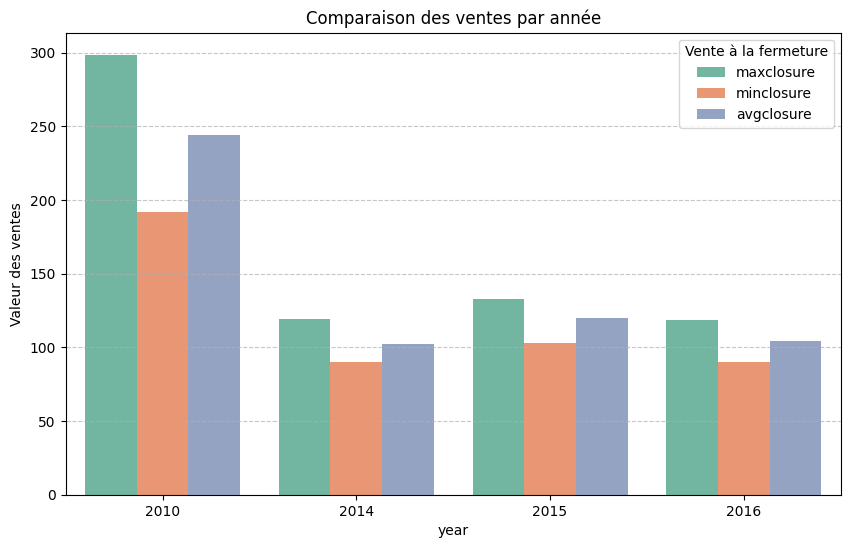

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas=sales300byyear.toPandas()

df_melted = df_pandas.melt(id_vars="year", var_name="Valeur à la fermeture", value_name="Valeur")


# Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x="year", y="Valeur", hue="Valeur à la fermeture", data=df_melted, palette="Set2")

# Ajout de labels et titre
plt.xlabel("year")
plt.ylabel("Valeur des ventes")
plt.title("Comparaison des ventes par année")
plt.legend(title="Vente à la fermeture")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Affichage
plt.show()


#### Conserver le résultat de la requête précédente en json :

In [87]:
# compléter votre réponse


Bravo !!!

Vous avez terminé cette introduction au Dataframe, vous pouvez fermer la connexion au cluster Spark.

In [34]:
spark.stop()

Vous pouvez arrêter les containers spark en ouvrant un terminal et en executant la commande suivante :